# 🎵 Music Genre Classification — CNN & CNN+GRU
### Target: 0.75+ Macro F1
**Strategy:** Single-phase training + SpecAugment + TTA

---
### ⚙️ Key Parameters
| Parameter | Default | Notes |
|-----------|---------|-------|
| `DURATION` | 10s | Fixed — drives spectrogram size |
| `N_MELS` | 128 | Mel bins — higher = finer freq resolution |
| `N_FFT` | 1024 | 64ms analysis window — captures harmonics |
| `HOP_LENGTH` | 512 | 32ms hop → ~312 time frames for 10s |
| `TRAIN_SIZE` | 2000 | Synthetic training samples |
| `EPOCHS` | 10 | Total training epochs |
| `LR` | 1e-3 | Initial learning rate (cosine-annealed to 1e-6) |
| `MODEL` | `'cnngru'` | `'cnn'` or `'cnngru'` |

> **WandB is optional** — set `USE_WANDB = True/False` in the wandb cell.


In [1]:
# ── CELL 1: Install libraries ──────────────────────────
!pip install -q torchmetrics wandb torchaudio

In [40]:
# ── CELL 2: Imports ────────────────────────────────────
import os, random, math, warnings
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchaudio
import torchaudio.transforms as T
from tqdm.notebook import tqdm
from torch.utils.data import Dataset, DataLoader
from torchmetrics.classification import MulticlassF1Score
from torch.cuda.amp import GradScaler, autocast
from concurrent.futures import ThreadPoolExecutor, as_completed
warnings.filterwarnings('ignore')
print('All imports done!')


All imports done!


In [41]:
# ── CELL 3: Seed for reproducibility ──────────────────
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(1729)
print('Seed set!')


Seed set!


In [56]:
# ── CELL 4: CONFIG ─────────────────────────────────────────────────────────
# -----------------------------------------------------------------------
# 🎛️  ARCHITECTURE
# -----------------------------------------------------------------------
MODEL = 'cnngru'          # 'cnn'  → SimpleCNN
                           # 'cnngru' → CNN + Bidirectional GRU

# -----------------------------------------------------------------------
# 🎵  AUDIO
# -----------------------------------------------------------------------
SAMPLE_RATE  = 16000
DURATION     = 20                        # seconds of audio per sample
MAX_LENGTH   = SAMPLE_RATE * DURATION

# -----------------------------------------------------------------------
# 🔊  MEL-SPECTROGRAM
# -----------------------------------------------------------------------
N_MELS       = 128
N_FFT        = 1024
HOP_LENGTH   = 512
F_MIN        = 2.0
F_MAX        = 8000.0
T_FRAMES = MAX_LENGTH // HOP_LENGTH + 1

# -----------------------------------------------------------------------
# 🏋️  TRAINING
# -----------------------------------------------------------------------
BATCH_SIZE   = 32
GRAD_ACCUM   = 1
NUM_WORKERS  = 4
PREFETCH     = 4

EPOCHS       = 13                        # total epochs, cosine-annealed
LR           = 5e-3                      # initial LR (anneals to eta_min)
WEIGHT_DECAY = 1e-5
PATIENCE     = 5                         # early stopping patience

TRAIN_SIZE   = 5000
NOISE_PROB   = 0.8
NOISE_LEVEL  = (0.03, 0.20)
N_TTA        = 5

# SpecAugment — single set of params (~20% time, ~20% freq)
TIME_MASK_PARAM = int(T_FRAMES // 5)    # ~20% of frames
FREQ_MASK_PARAM = int(N_MELS  * 0.20)   # ~20% of 128 bins

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
N_GPUS = torch.cuda.device_count()
print(f'Device       : {DEVICE}  ({N_GPUS} GPU(s))')
print(f'Model        : {MODEL}')
print(f'Duration     : {DURATION}s  |  MAX_LENGTH: {MAX_LENGTH:,}')
print(f'Spectrogram  : N_MELS={N_MELS}, N_FFT={N_FFT}, HOP={HOP_LENGTH}')
print(f'Time frames  : ~{T_FRAMES}  |  Spec shape: ({N_MELS} × {T_FRAMES})')
print(f'Train size   : {TRAIN_SIZE}  |  Batch: {BATCH_SIZE}')
print(f'Epochs       : {EPOCHS} (LR={LR} → cosine anneal to 1e-6)')
print(f'SpecAugment  : time={TIME_MASK} frames, freq={FREQ_MASK} bins')


Device       : cuda  (2 GPU(s))
Model        : cnngru
Duration     : 20s  |  MAX_LENGTH: 320,000
Spectrogram  : N_MELS=128, N_FFT=1024, HOP=512
Time frames  : ~626  |  Spec shape: (128 × 626)
Train size   : 5000  |  Batch: 32
Epochs       : 13 (LR=0.001 → cosine anneal to 1e-6)
SpecAugment  : time=125 frames, freq=25 bins


In [58]:
# ── CELL 5: WandB — OPTIONAL ─────────────────────────────────────────────────
USE_WANDB = True   # ← flip this to True to enable

import wandb

run = None

if USE_WANDB:
    try:
        from kaggle_secrets import UserSecretsClient
        user_secrets   = UserSecretsClient()
        secret_value_0 = user_secrets.get_secret("WANDB_API_KEY")
        wandb.login(key=secret_value_0)

        run = wandb.init(
            entity  = "24f1002643-indian-institute-of-technology-madras",
            project = "24f1002643-t12026",
            config  = {
                'model'        : MODEL,
                'duration'     : DURATION,
                'n_mels'       : N_MELS,
                'n_fft'        : N_FFT,
                'hop_length'   : HOP_LENGTH,
                'train_size'   : TRAIN_SIZE,
                'batch_size'   : BATCH_SIZE,
                'lr'           : LR,
                'epochs'       : EPOCHS,
                'noise_prob'   : NOISE_PROB,
                'n_tta'        : N_TTA,
                'weight_decay' : WEIGHT_DECAY,
            }
        )
        print(f'✅ WandB run initialised: {run.name}')
    except Exception as e:
        print(f'⚠️  WandB disabled — {e}')
        USE_WANDB = False
        run = None
else:
    print('ℹ️  WandB skipped (USE_WANDB=False)')


def wandb_log(metrics: dict):
    if USE_WANDB and run is not None:
        run.log(metrics)

def wandb_save(path: str):
    if USE_WANDB and run is not None:
        run.save(path)

def wandb_finish():
    if USE_WANDB and run is not None:
        run.finish()


wandb: WARNING Calling wandb.login() after wandb.init() has no effect.


✅ WandB run initialised: colorful-surf-8


In [44]:
# ── CELL 6: Paths & Labels ─────────────────────────────
BASE_PATH      = '/kaggle/input/competitions/jan-2026-dl-gen-ai-project/messy_mashup'
# BASE_PATH      = '/kaggle/input/jan-2026-dl-gen-ai-project/messy_mashup'
GENRES_PATH    = os.path.join(BASE_PATH, 'genres_stems')
ESC_PATH       = os.path.join(BASE_PATH, 'ESC-50-master', 'audio')
REQUIRED_STEMS = ['drums.wav', 'vocals.wav', 'bass.wav', 'other.wav']

GENRES   = ['blues','classical','country','disco','hiphop',
            'jazz','metal','pop','reggae','rock']
label2id = {g: i for i, g in enumerate(GENRES)}
id2label = {i: g for g, i in label2id.items()}
NUM_LABELS = len(GENRES)

print('Paths set!')
print('label2id:', label2id)


Paths set!
label2id: {'blues': 0, 'classical': 1, 'country': 2, 'disco': 3, 'hiphop': 4, 'jazz': 5, 'metal': 6, 'pop': 7, 'reggae': 8, 'rock': 9}


In [45]:
# ── CELL 7: Build Song Index ───────────────────────────
def build_song_index():
    index = {}
    for genre in GENRES:
        genre_path = os.path.join(GENRES_PATH, genre)
        valid = []
        for folder in sorted(os.listdir(genre_path)):
            folder_path = os.path.join(genre_path, folder)
            if not os.path.isdir(folder_path):
                continue
            if all(os.path.exists(os.path.join(folder_path, s))
                   for s in REQUIRED_STEMS):
                valid.append(folder_path)
        index[genre] = valid
        print(f'  {genre}: {len(valid)} songs')
    return index

song_index = build_song_index()

noise_files = []
for root, _, files in os.walk(ESC_PATH):
    for f in files:
        if f.endswith('.wav'):
            noise_files.append(os.path.join(root, f))

print(f'\nNoise files: {len(noise_files)}')


  blues: 100 songs
  classical: 100 songs
  country: 100 songs
  disco: 100 songs
  hiphop: 100 songs
  jazz: 100 songs
  metal: 100 songs
  pop: 100 songs
  reggae: 100 songs
  rock: 100 songs

Noise files: 2000


In [46]:
# ── CELL 8: Train / Val Split ──────────────────────────
train_index = {}
val_index   = {}

for genre in GENRES:
    songs = song_index[genre][:]
    random.shuffle(songs)
    split = int(0.85 * len(songs))
    train_index[genre] = songs[:split]
    val_index[genre]   = songs[split:]
    print(f'  {genre} → Train: {len(train_index[genre])}, Val: {len(val_index[genre])}')

print('\nTrain/Val split done!')


  blues → Train: 85, Val: 15
  classical → Train: 85, Val: 15
  country → Train: 85, Val: 15
  disco → Train: 85, Val: 15
  hiphop → Train: 85, Val: 15
  jazz → Train: 85, Val: 15
  metal → Train: 85, Val: 15
  pop → Train: 85, Val: 15
  reggae → Train: 85, Val: 15
  rock → Train: 85, Val: 15

Train/Val split done!


In [47]:
# ── CELL 9: Audio Helper Functions ────────────────────────────────────────────

def load_audio(path: str) -> torch.Tensor:
    """Load mono audio at SAMPLE_RATE.  Returns float32 Tensor (T,)."""
    waveform, sr = torchaudio.load(path)
    if sr != SAMPLE_RATE:
        waveform = torchaudio.functional.resample(waveform, sr, SAMPLE_RATE)
    if waveform.shape[0] > 1:
        waveform = waveform.mean(0, keepdim=True)
    return waveform.squeeze(0)

def normalize(audio: torch.Tensor) -> torch.Tensor:
    return audio / (audio.abs().max() + 1e-6)

def crop_random(audio: torch.Tensor) -> torch.Tensor:
    """Random crop — training augmentation."""
    length = audio.shape[0]
    if length >= MAX_LENGTH:
        start = random.randint(0, length - MAX_LENGTH)
        return audio[start : start + MAX_LENGTH]
    return F.pad(audio, (0, MAX_LENGTH - length))

def crop_center(audio: torch.Tensor) -> torch.Tensor:
    """Centre crop — validation (reproducible)."""
    length = audio.shape[0]
    if length >= MAX_LENGTH:
        start = (length - MAX_LENGTH) // 2
        return audio[start : start + MAX_LENGTH]
    return F.pad(audio, (0, MAX_LENGTH - length))

def random_gain(audio: torch.Tensor) -> torch.Tensor:
    return audio * random.uniform(0.7, 1.3)

def add_noise(audio: torch.Tensor) -> torch.Tensor:
    """Mix in a random pre-loaded ESC-50 clip — zero disk I/O."""
    if random.random() < NOISE_PROB and len(noise_arrays) > 0:
        noise = random.choice(noise_arrays).float()
        noise = crop_random(noise)
        level = random.uniform(*NOISE_LEVEL)
        audio = audio + level * noise
    return audio

print('Audio helpers ready!')


Audio helpers ready!


In [10]:
# ── CELL 10: Pre-load ESC-50 Noise Files to RAM (DataLoader) ───────────────
class _PathDataset(Dataset):
    """Minimal Dataset: index → load file → float16 Tensor."""
    def __init__(self, paths):
        self.paths = paths
    def __len__(self):
        return len(self.paths)
    def __getitem__(self, i):
        try:
            return load_audio(self.paths[i]).half()
        except Exception:
            return None

print(f'Pre-loading {len(noise_files)} ESC-50 noise files to RAM ({NUM_WORKERS} workers)...')
_noise_ds     = _PathDataset(noise_files)
_noise_loader = DataLoader(
    _noise_ds,
    batch_size  = 1,
    num_workers = NUM_WORKERS,
    collate_fn  = lambda b: b[0],   # unwrap the outer batch-list; tensor stays as-is
    pin_memory  = False,            # already going to CPU RAM, not GPU
)
noise_arrays: list[torch.Tensor] = [
    t for t in tqdm(_noise_loader, desc='Loading noise') if t is not None
]
total_mb = sum(t.nbytes for t in noise_arrays) / 1e6
print(f'Loaded {len(noise_arrays)}/{len(noise_files)} noise clips | {total_mb:.0f} MB (float16)')
print()


# ── CELL 11: Pre-load ALL Song Stems to RAM (DataLoader) ───────────────────
class _StemDataset(Dataset):
    """Flat dataset over (key, path) pairs → returns (key, float16 Tensor)."""
    def __init__(self, jobs):           # jobs: list of ((song_path, stem), full_path)
        self.jobs = jobs
    def __len__(self):
        return len(self.jobs)
    def __getitem__(self, i):
        key, path = self.jobs[i]
        try:
            return key, load_audio(path).half()
        except Exception:
            return key, None

def _load_stems(jobs, desc):
    cache: dict[tuple, torch.Tensor] = {}
    ds     = _StemDataset(jobs)
    loader = DataLoader(
        ds,
        batch_size  = 1,
        num_workers = NUM_WORKERS,
        collate_fn  = lambda b: b[0],  # unwrap; returns (key, tensor)
        pin_memory  = False,
    )
    for key, tensor in tqdm(loader, desc=desc):
        if tensor is not None:
            cache[key] = tensor
    return cache

# ── TRAIN stems ──────────────────────────────────────────────────────────────
train_jobs = [(( song, stem), os.path.join(song, stem))
              for genre in GENRES
              for song  in train_index[genre]
              for stem  in REQUIRED_STEMS]
print(f'Pre-loading {len(train_jobs)} TRAIN stems ({NUM_WORKERS} workers)...')
stem_cache = _load_stems(train_jobs, 'Train stems')
train_mb   = sum(t.nbytes for t in stem_cache.values()) / 1e6
print(f'Train stem cache : {len(stem_cache)} tensors | {train_mb:.0f} MB (float16)')

# ── VAL stems ────────────────────────────────────────────────────────────────
val_jobs = [((song, stem), os.path.join(song, stem))
            for genre in GENRES
            for song  in val_index[genre]
            for stem  in REQUIRED_STEMS]
print(f'\nPre-loading {len(val_jobs)} VAL stems ({NUM_WORKERS} workers)...')
val_cache = _load_stems(val_jobs, 'Val stems')
val_mb    = sum(t.nbytes for t in val_cache.values()) / 1e6
print(f'Val stem cache   : {len(val_cache)} tensors | {val_mb:.0f} MB (float16)')
print(f'\nTotal stem RAM   : {train_mb + val_mb:.0f} MB')

Pre-loading 2000 ESC-50 noise files to RAM (4 workers)...


Loading noise:   0%|          | 0/2000 [00:00<?, ?it/s]

Loaded 2000/2000 noise clips | 320 MB (float16)

Pre-loading 3400 TRAIN stems (4 workers)...


Train stems:   0%|          | 0/3400 [00:00<?, ?it/s]

Train stem cache : 3400 tensors | 3267 MB (float16)

Pre-loading 600 VAL stems (4 workers)...


Val stems:   0%|          | 0/600 [00:00<?, ?it/s]

Val stem cache   : 600 tensors | 576 MB (float16)

Total stem RAM   : 3843 MB


In [48]:
# ── CELL 12: GPU Mel-Spectrogram Transform ────────────────────────────────────
# Purpose: Convert raw waveforms → 2D mel spectrograms on GPU for CNN input.
#
# Why these parameters for CNN/GRU?
# ─────────────────────────────────
# N_FFT=1024 (64ms window): captures full pitch cycles + harmonic overtones,
#   which are critical for genre discrimination (e.g. classical vs metal).
# HOP_LENGTH=512 (32ms, 50% overlap): gives ~312 frames for 10s — enough
#   temporal resolution for rhythm/tempo patterns without making the sequence
#   too long for the GRU.
# N_MELS=128: standard for music, covers all perceptually relevant bands.
# F_MIN=20Hz: includes sub-bass frequencies (important for bass/kick distinction).
#
# Normalisation: per-batch mean/std instead of AST's fixed constants,
#   which is more appropriate for a model trained from scratch.

class GPUMelTransform(nn.Module):
    """
    Batched GPU pipeline: raw waveform → normalised log-mel spectrogram.
    Returns (B, 1, N_MELS, T_FRAMES) — 4D tensor ready for nn.Conv2d.
    SpecAugment applied during training (mild Phase 1 / strong Phase 2).
    """

    def __init__(
        self,
        sample_rate     = SAMPLE_RATE,
        n_mels          = N_MELS,
        n_fft           = N_FFT,
        hop_length      = HOP_LENGTH,
        f_min           = F_MIN,
        f_max           = F_MAX,
        time_mask_param = TIME_MASK_PARAM,
        freq_mask_param = FREQ_MASK_PARAM,
    ):
        super().__init__()
        self.mel_spec = T.MelSpectrogram(
            sample_rate = sample_rate,
            n_fft       = n_fft,
            hop_length  = hop_length,
            n_mels      = n_mels,
            f_min       = f_min,
            f_max       = f_max,
            power       = 2.0,
            center      = True,
        )
        self.amplitude_to_db = T.AmplitudeToDB(stype='power', top_db=80)
        # SpecAugment — re-created when mask params change between phases
        self._build_augment(time_mask_param, freq_mask_param)

    def _build_augment(self, time_mask_param, freq_mask_param):
        """Re-initialise SpecAugment transforms (call between phases)."""
        self.time_mask = T.TimeMasking(time_mask_param, iid_masks=True)
        self.freq_mask = T.FrequencyMasking(freq_mask_param, iid_masks=True)

    def forward(self, waveforms: torch.Tensor, augment: bool = False) -> torch.Tensor:
        """
        Args:
            waveforms : (B, T)  float32 — raw audio on GPU
            augment   : bool    — apply SpecAugment (True during training)
        Returns:
            spec      : (B, 1, N_MELS, T_FRAMES) — ready for Conv2d
        """
        spec = self.mel_spec(waveforms)       # (B, N_MELS, T_FRAMES)
        spec = self.amplitude_to_db(spec)      # log scale, top_db clipped

        # Per-batch normalisation (zero-mean, unit-variance)
        mean = spec.mean(dim=(1, 2), keepdim=True)
        std  = spec.std(dim=(1, 2), keepdim=True) + 1e-6
        spec = (spec - mean) / std

        if augment:
            spec = self.time_mask(spec)
            spec = self.freq_mask(spec)

        return spec.unsqueeze(1)   # (B, 1, N_MELS, T_FRAMES)


gpu_transform = GPUMelTransform().to(DEVICE)
print('GPUMelTransform ready on', DEVICE)

with torch.no_grad():
    dummy = torch.randn(2, MAX_LENGTH).to(DEVICE)
    out = gpu_transform(dummy, augment=True)
    print(f'Transform output shape : {out.shape}   (B, 1, N_MELS, T_FRAMES)')
    print(f'Expected               : (2, 1, {N_MELS}, ~{MAX_LENGTH // HOP_LENGTH + 1})')


GPUMelTransform ready on cuda
Transform output shape : torch.Size([2, 1, 128, 626])   (B, 1, N_MELS, T_FRAMES)
Expected               : (2, 1, 128, ~626)


In [59]:
# ═══════════════════════════════════════════════════════════════════════════════
#  CELL 13 – Model Definitions  (ImprovedCNN  &  ImprovedCNNGRU)
# ═══════════════════════════════════════════════════════════════════════════════
#
#  Targets: GTZAN 10-class genre classification + ESC-50 noise augmentation.
#
#  Design principles
#  ─────────────────
#  • Residual (skip) connections  → stable gradients, allows deeper networks
#  • Dilated convolutions          → expands receptive field for free
#  • No AdaptiveAvgPool anywhere   → exact, reproducible, fixed-size pooling
#  • Learned temporal attention    → suppresses noise-corrupted frames in GRU
#  • Dropout2d + Dropout           → spatial + channel regularisation
#
#  ┌──────────────────────────────────────────────────────────────────────────┐
#  │  ImprovedCNN                                                             │
#  │  Stem (stride-2) → 3 × ResBlock (stride-2) → 1 × dilated ResBlock      │
#  │  MaxPool2d((_H4, _W4)) → Flatten(256) → FC(256→128→10)                 │
#  │  ~2.4 M params                                                           │
#  └──────────────────────────────────────────────────────────────────────────┘
#
#  ┌──────────────────────────────────────────────────────────────────────────┐
#  │  ImprovedCNNGRU                                                          │
#  │  4 × FreqResBlock (MaxPool freq-only) → (B, 64, 8, 312)                 │
#  │  Reshape → (B, T=312, 512) → BiGRU(512, 256×2, 2L)                     │
#  │  TemporalAttention (linear softmax) → FC(512→128→10)                    │
#  │  ~3.2 M params                                                           │
#  └──────────────────────────────────────────────────────────────────────────┘

import math
import torch
import torch.nn as nn

# ── Spatial dimension constants (GTZAN fixed-size mel-spec) ──────────────────
#
#  Input: (B, 1, N_MELS=128, T_FRAMES=312)
#
#  stride-2 conv with k=3, pad=1:  out = floor((in + 2·1 − 3) / 2) + 1
#  This differs from MaxPool2d(2,2): out = floor(in / 2)
#  So we compute the exact chain for the time dimension.

def _conv_out(n: int, k: int = 3, s: int = 2, p: int = 1) -> int:
    """Spatial output size of a single Conv2d / MaxPool2d layer."""
    return (n + 2 * p - k) // s + 1

_H0, _W0 = N_MELS, T_FRAMES                    # raw input spatial dims
# Stem + 3 stride-2 ResBlocks = 4 halvings
_H4 = _conv_out(_conv_out(_conv_out(_conv_out(_H0))))   # 128 → 8
_W4 = _conv_out(_conv_out(_conv_out(_conv_out(_W0))))   # 312 → 20


# ── Shared building blocks ───────────────────────────────────────────────────

class _ResBlock(nn.Module):
    """
    Post-activation residual block.

    Parameters
    ----------
    in_ch, out_ch : int
        Input / output channel counts.
    stride : int
        Applied to the first conv and the 1×1 skip projection.
        Use stride=2 to halve both spatial dimensions.
    dilation : int
        Receptive-field multiplier.  padding=dilation keeps spatial size
        unchanged (standard 'same' padding for dilated k=3 conv).
    drop2d : float
        Dropout2d probability inside the residual branch.
    """
    def __init__(self, in_ch: int, out_ch: int,
                 stride: int = 1, dilation: int = 1,
                 drop2d: float = 0.0):
        super().__init__()
        p = dilation                         # same-padding for k=3 dilated conv
        self.branch = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3,
                      stride=stride, padding=p, dilation=dilation, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, 3,
                      padding=p, dilation=dilation, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.Dropout2d(drop2d),
        )
        # Skip projection: 1×1 conv to match channels / stride.
        # Identity when shapes already match (no extra cost).
        self.skip = (
            nn.Sequential(
                nn.Conv2d(in_ch, out_ch, 1, stride=stride, bias=False),
                nn.BatchNorm2d(out_ch),
            )
            if in_ch != out_ch or stride != 1
            else nn.Identity()
        )
        self.act = nn.ReLU(inplace=True)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.act(self.branch(x) + self.skip(x))

# ── ImprovedCNN ───────────────────────────────────────────────────────────────

class AudioCNN(nn.Module):
    """
    Residual CNN for GTZAN genre classification, robust to ESC-50 noise.

    Forward pass dimensions (N_MELS=128, T_FRAMES=312)
    ────────────────────────────────────────────────────
    Input          (B,   1, 128, 312)
    Stem           (B,  32,  64, 156)   ← stride-2 conv
    Stage 1        (B,  64,  32,  78)   ← ResBlock s2
    Stage 2        (B, 128,  16,  39)   ← ResBlock s2
    Stage 3        (B, 256,   8,  20)   ← ResBlock s2
    Context        (B, 256,   8,  20)   ← dilated ResBlock, dilation=2
    GlobalMaxPool  (B, 256,   1,   1)   ← MaxPool2d((_H4, _W4))
    Flatten        (B, 256)
    FC → logits    (B,  10)

    Why no AdaptiveAvgPool
    ─────────────────────
    We use an exact MaxPool2d whose kernel equals the remaining spatial size
    (_H4 × _W4, computed at import time from the known input shape).
    This is reproducible, deterministic, and avoids the implicit assumption
    that adaptive pooling makes about the input size being variable.
    """
    def __init__(self, n_classes: int = NUM_LABELS, dropout: float = 0.4):
        super().__init__()

        # Initial conv: stride-2 halves spatial dims once
        self.stem = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
        )                                               # → (B, 32,  64, 156)

        # Three stride-2 residual stages
        self.stage1 = _ResBlock( 32,  64, stride=2, drop2d=0.20)  # → (B, 64, 32, 78)
        self.stage2 = _ResBlock( 64, 128, stride=2, drop2d=0.20)  # → (B,128, 16, 39)
        self.stage3 = _ResBlock(128, 256, stride=2, drop2d=0.30)  # → (B,256,  8, 20)

        # Context block: dilation=2 → effective kernel 5×5, same spatial size.
        # Wider receptive field helps the model ignore localised noise bursts.
        self.context = _ResBlock(256, 256, dilation=2, drop2d=0.20)

        # Exact global max-pool: kernel = remaining spatial dims after 4 halvings.
        # _H4 and _W4 are computed at module level from the input constants.
        self.global_pool = nn.MaxPool2d(kernel_size=(_H4, _W4))    # → (B,256,1,1)

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256, 128), nn.ReLU(inplace=True),
            nn.Dropout(dropout),
            nn.Linear(128, n_classes),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = self.stem(x)           # (B,  32,  64, 156)
        x = self.stage1(x)         # (B,  64,  32,  78)
        x = self.stage2(x)         # (B, 128,  16,  39)
        x = self.stage3(x)         # (B, 256,   8,  20)
        x = self.context(x)        # (B, 256,   8,  20)
        x = self.global_pool(x)    # (B, 256,   1,   1)
        return self.classifier(x)
 
 
class _LightFreqResBlock(nn.Module):
    """
    Lightweight residual block: smaller channels, higher Dropout2d,
    freq-only MaxPool.
    """
    def __init__(self, in_ch: int, out_ch: int, drop2d: float = 0.40):
        super().__init__()
        self.branch = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.Dropout2d(drop2d),
        )
        self.skip = (
            nn.Sequential(
                nn.Conv2d(in_ch, out_ch, 1, bias=False),
                nn.BatchNorm2d(out_ch),
            ) if in_ch != out_ch else nn.Identity()
        )
        self.act  = nn.ReLU(inplace=True)
        self.pool = nn.MaxPool2d(kernel_size=(2, 1))    # halve freq, keep time
 
    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.pool(self.act(self.branch(x) + self.skip(x)))
 
 
class _TemporalAttention(nn.Module):
    """Soft attention over time axis.  Input (B, T, H) → output (B, H)."""
    def __init__(self, hidden_dim: int):
        super().__init__()
        self.score = nn.Linear(hidden_dim, 1, bias=False)
 
    def forward(self, x: torch.Tensor) -> torch.Tensor:
        w = torch.softmax(self.score(x), dim=1)    # (B, T, 1)
        return (x * w).sum(dim=1)                   # (B, H)
 
 
class AudioCNNGRU(nn.Module):
    """
    Lightweight CNN-GRU for GTZAN with ≤ 5 K training samples.
 
    Forward pass dimensions (N_MELS=128, T_FRAMES=312)
    ────────────────────────────────────────────────────
    Input           (B,   1, 128, 312)
    LightFreqRes×3  (B,  32,  16, 312)  ← freq 128→64→32→16, time untouched
    Reshape         (B, 312, 512)        ← flatten freq & channel dims
    Projection      (B, 312,  64)        ← Linear(512, 64) + BN + ReLU + Drop
    BiGRU(1L)       (B, 312, 128)        ← hidden=64, bidir
    TempAttn        (B, 128)
    FC              (B,  10)
 
    Parameters: ~193–230 K  (vs ~3.2 M in ImprovedCNNGRU)
    """
    def __init__(self,
                 n_mels:     int   = 128,
                 n_classes:  int   = 10,
                 cnn_drop:   float = 0.40,
                 proj_drop:  float = 0.50,
                 gru_hidden: int   = 64,
                 fc_drop:    float = 0.50):
        super().__init__()
 
        # ── CNN front-end ────────────────────────────────────────────────────
        # Channels:  1 →  16 → 32 → 32
        # Freq:    128 →  64 → 32 → 16   (3 × MaxPool(2,1))
        # Time:    312 unchanged
        self.cnn = nn.Sequential(
            _LightFreqResBlock(  1, 16, drop2d=cnn_drop),   # (B, 16,  64, 312)
            _LightFreqResBlock( 16, 32, drop2d=cnn_drop),   # (B, 32,  32, 312)
            _LightFreqResBlock( 32, 32, drop2d=cnn_drop),   # (B, 32,  16, 312)
        )
 
        cnn_out_dim = 32 * (n_mels // 8)   # 32 × 16 = 512
 
        # ── Bottleneck projection  (main param saver) ─────────────────────
        proj_dim = 64
        self.proj = nn.Sequential(
            nn.Linear(cnn_out_dim, proj_dim, bias=False),
            nn.BatchNorm1d(proj_dim),
            nn.ReLU(inplace=True),
            nn.Dropout(proj_drop),
        )
 
        # ── Bidirectional GRU ─────────────────────────────────────────────
        self.gru = nn.GRU(
            input_size    = proj_dim,
            hidden_size   = gru_hidden,
            num_layers    = 1,               # 1 layer: no inter-layer dropout
            batch_first   = True,
            bidirectional = True,
        )
 
        # ── Temporal attention + classifier ───────────────────────────────
        self.attn = _TemporalAttention(gru_hidden * 2)
 
        self.classifier = nn.Sequential(
            nn.Linear(gru_hidden * 2, 64),
            nn.ReLU(inplace=True),
            nn.Dropout(fc_drop),
            nn.Linear(64, n_classes),
        )
 
    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = self.cnn(x)                         # (B, 32,  16, T)
        B, C, F, T = x.shape
        x = x.view(B, C * F, T)                 # (B, 512,   T)
        x = x.permute(0, 2, 1)                  # (B,   T, 512)
        x = self.proj(x.reshape(B * T, -1))\
               .view(B, T, -1)                  # (B,   T,  64)
        x, _ = self.gru(x)                      # (B,   T, 128)
        x = self.attn(x)                         # (B, 128)
        return self.classifier(x)
        


# ── Instantiate ───────────────────────────────────────────────────────────────

if MODEL == 'cnn':
    model = AudioCNN(n_classes=NUM_LABELS)
elif MODEL == 'cnngru':
    model = AudioCNNGRU(n_mels=N_MELS, n_classes=NUM_LABELS)
else:
    raise ValueError(f"Unknown MODEL='{MODEL}'. Use 'cnn' or 'cnngru'.")

model.to(DEVICE)

if N_GPUS > 1:
    model = nn.DataParallel(model)
    print(f'DataParallel across {N_GPUS} GPUs')

if torch.cuda.is_available() and torch.cuda.get_device_capability()[0] >= 7:
    model = torch.compile(model)
    print(f'torch.compile enabled on {torch.cuda.get_device_name()}')


def _inner(m):
    """Unwrap DataParallel / compiled model to access raw state dict."""
    if hasattr(m, 'module'):    m = m.module
    if hasattr(m, '_orig_mod'): m = m._orig_mod
    return m

def save_model(m, path):
    torch.save(_inner(m).state_dict(), path)

def load_model(m, path):
    _inner(m).load_state_dict(torch.load(path, weights_only=True))


total_params = sum(p.numel() for p in _inner(model).parameters())
print(f'Model        : {MODEL.upper()}  (Improved)')
print(f'_H4 × _W4    : {_H4} × {_W4}  (global pool kernel)')
print(f'Total params : {total_params:,}')

DataParallel across 2 GPUs
torch.compile enabled on Tesla T4
Model        : CNNGRU  (Improved)
_H4 × _W4    : 8 × 40  (global pool kernel)
Total params : 127,498


In [60]:
# ── CELL 10: Training Dataset (Synthetic Mashups — RAM-only) ──────────────
# All stems are already in stem_cache (float16 Tensors, loaded in Cell 9b).
# __getitem__ does ZERO disk I/O:
#   1. Pick genre + stems  →  fetch from stem_cache (RAM)
#   2. .float() conversion  →  cheap CPU op, no allocation
#   3. crop / gain / mix / noise  →  all PyTorch tensor ops
#   4. Return waveform Tensor (T,) ready for pin_memory → GPU transfer

class TrainDataset(Dataset):
    """
    Generates TRAIN_SIZE synthetic mashups from RAM-cached stems.
    Returns raw float32 waveform — spectrogram computed on GPU in train loop.
    """
    def __init__(self, song_index, size=TRAIN_SIZE):
        self.song_index = song_index
        self.size       = size

    def __len__(self):
        return self.size

    def __getitem__(self, idx):
        while True:
            try:
                genre = random.choice(GENRES)
                # genre = GENRES[idx % len(GENRES)]
                songs = self.song_index[genre]
                if not songs:
                    continue

                # Cross-song mixing — every stem from a different song
                mixed: torch.Tensor | None = None
                all_found = True
                for stem in REQUIRED_STEMS:
                    song_path = random.choice(songs)
                    cached = stem_cache.get((song_path, stem))
                    if cached is None:
                        all_found = False
                        break
                    audio = cached.float()      # float16 → float32 (in-place free)
                    audio = crop_random(audio)
                    audio = random_gain(audio)
                    mixed = audio if mixed is None else mixed + audio

                if not all_found or mixed is None:
                    continue

                mixed = normalize(mixed)
                mixed = add_noise(mixed)        # noise from RAM — no disk I/O
                mixed = normalize(mixed)

                return {
                    'waveform': mixed,                                    # (T,) float32
                    'label'   : torch.tensor(label2id[genre], dtype=torch.long)
                }
            except Exception:
                continue

print('TrainDataset class defined! (RAM-only, zero disk I/O in __getitem__)')


# ── CELL 11: Validation Dataset (Fixed Crops — RAM-only) ──────────────────
# All val stems are already in val_cache (Cell 9b) — mixed once at init time.
# __getitem__ is just a list lookup: zero disk I/O, zero recomputation.

class ValDataset(Dataset):
    """
    Pre-mixes all validation songs at construction time and stores them as
    (waveform, label) tuples in RAM.  Fully reproducible (centre-crop).
    """
    def __init__(self, song_index):
        self.samples: list[tuple[torch.Tensor, int]] = []
        for genre in GENRES:
            for song_path in song_index[genre]:
                mixed: torch.Tensor | None = None
                ok = True
                for stem in REQUIRED_STEMS:
                    cached = val_cache.get((song_path, stem))
                    if cached is None:
                        ok = False
                        break
                    audio = cached.float()      # float16 → float32
                    audio = crop_center(audio)
                    mixed = audio if mixed is None else mixed + audio
                if ok and mixed is not None:
                    self.samples.append((normalize(mixed), label2id[genre]))

        print(f'ValDataset: {len(self.samples)} samples pre-mixed into RAM')

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        waveform, label = self.samples[idx]
        return {
            'waveform': waveform,
            'label'   : torch.tensor(label, dtype=torch.long)
        }

print('ValDataset class defined! (all samples pre-mixed in RAM)')


TrainDataset class defined! (RAM-only, zero disk I/O in __getitem__)
ValDataset class defined! (all samples pre-mixed in RAM)


In [61]:
# ── CELL 15: Create DataLoaders ────────────────────────
train_dataset = TrainDataset(train_index, size=TRAIN_SIZE)
val_dataset   = ValDataset(val_index)

train_loader = DataLoader(
    train_dataset,
    batch_size         = BATCH_SIZE,
    shuffle            = True,
    num_workers        = NUM_WORKERS,
    pin_memory         = True,
    persistent_workers = True,
    prefetch_factor    = PREFETCH,
)
val_loader = DataLoader(
    val_dataset,
    batch_size         = BATCH_SIZE,
    shuffle            = False,
    num_workers        = NUM_WORKERS,
    pin_memory         = True,
    persistent_workers = True,
    prefetch_factor    = PREFETCH,
)

print(f'Train samples : {len(train_dataset)}')
print(f'Val samples   : {len(val_dataset)}')
print(f'Train batches : {len(train_loader)}')
print(f'Val batches   : {len(val_loader)}')


ValDataset: 150 samples pre-mixed into RAM
Train samples : 5000
Val samples   : 150
Train batches : 157
Val batches   : 5


In [62]:
# ── CELL 16: Loss + F1 Metric ──────────────────────────
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
f1_metric = MulticlassF1Score(
    num_classes = NUM_LABELS,
    average     = 'macro'
).to(DEVICE)

print('Loss  : CrossEntropyLoss (label_smoothing=0.1)')
print('Metric: Macro F1 Score')


Loss  : CrossEntropyLoss (label_smoothing=0.1)
Metric: Macro F1 Score


In [63]:
# ── CELL 17: Optimizer & Scheduler ──────────────────────────────────────────
#
# CosineAnnealingLR from PyTorch — no warmup.
# LR starts at LR (1e-3) and follows a cosine curve down to eta_min (1e-6)
# over EPOCHS epochs.  Stepped once per epoch after validation.

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr           = LR,
    weight_decay = WEIGHT_DECAY,
)

scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max   = EPOCHS,
    eta_min = 1e-6,
)

print(f'Optimizer : AdamW  lr={LR}, weight_decay={WEIGHT_DECAY}')
print(f'Scheduler : CosineAnnealingLR  T_max={EPOCHS}, eta_min=1e-6')


Optimizer : AdamW  lr=0.001, weight_decay=0.0001
Scheduler : CosineAnnealingLR  T_max=13, eta_min=1e-6


In [64]:
# ── CELL 18: Train / Validate Functions ──────────────────────────────────────

scaler = GradScaler()

def train_one_epoch(model, loader, optimizer):
    model.train()
    f1_metric.reset()
    total_loss = 0
    optimizer.zero_grad()

    for step, batch in enumerate(tqdm(loader, desc='Training')):
        waveforms = batch['waveform'].to(DEVICE, non_blocking=True)
        labels    = batch['label'].to(DEVICE, non_blocking=True)

        with autocast():
            spec   = gpu_transform(waveforms, augment=True)
            logits = model(spec)
            loss   = criterion(logits, labels) / GRAD_ACCUM

        scaler.scale(loss).backward()

        if (step + 1) % GRAD_ACCUM == 0 or (step + 1) == len(loader):
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            scaler.step(optimizer)
            scaler.update()
            optimizer.zero_grad()

        total_loss += loss.item() * GRAD_ACCUM
        preds = torch.argmax(logits, dim=1)
        f1_metric.update(preds, labels)

    return total_loss / len(loader), f1_metric.compute().item()


def validate(model, loader):
    model.eval()
    f1_metric.reset()
    total_loss = 0
    with torch.no_grad():
        for batch in tqdm(loader, desc='Validation'):
            waveforms = batch['waveform'].to(DEVICE, non_blocking=True)
            labels    = batch['label'].to(DEVICE, non_blocking=True)
            with autocast():
                spec   = gpu_transform(waveforms, augment=False)
                logits = model(spec)
                loss   = criterion(logits, labels)
            preds = torch.argmax(logits, dim=1)
            f1_metric.update(preds, labels)
            total_loss += loss.item()
    return total_loss / len(loader), f1_metric.compute().item()

print('Train / Validate functions defined!')


Train / Validate functions defined!


In [65]:
# ── CELL 19: Training ────────────────────────────────────────────────────────
#
# Single training loop — no phases, no warmup.
# scheduler.step() called once per epoch (correct for CosineAnnealingLR).

gpu_transform._build_augment(TIME_MASK, FREQ_MASK)
print(f'SpecAugment — time mask: {TIME_MASK} frames  |  freq mask: {FREQ_MASK} bins')

best_f1      = 0.0
patience_cnt = 0

print(f'\n{"="*55}')
print(f'Training  ({EPOCHS} epochs, LR={LR} → cosine → 1e-6)')
print(f'  All {sum(p.numel() for p in model.parameters()):,} params trainable')
print(f'{"="*55}\n')

for epoch in range(EPOCHS):
    train_loss, train_f1 = train_one_epoch(model, train_loader, optimizer)
    val_loss,   val_f1   = validate(model, val_loader)
    scheduler.step()

    wandb_log({
        'epoch'      : epoch,
        'train/loss' : train_loss,
        'train/f1'   : train_f1,
        'val/loss'   : val_loss,
        'val/f1'     : val_f1,
        'lr'         : scheduler.get_last_lr()[0],
    })

    print(f'Epoch {epoch+1}/{EPOCHS}  |  LR: {scheduler.get_last_lr()[0]:.2e}')
    print(f'  Train Loss : {train_loss:.4f}  |  Train F1 : {train_f1:.4f}')
    print(f'  Val   Loss : {val_loss:.4f}  |  Val   F1 : {val_f1:.4f}')

    if val_f1 > best_f1:
        best_f1 = val_f1
        save_model(model, '/kaggle/working/best_model.pth')
        wandb_save('/kaggle/working/best_model.pth')
        patience_cnt = 0
        print(f'  ✓ Saved best model (val F1: {best_f1:.4f})')
    else:
        patience_cnt += 1
        if patience_cnt >= PATIENCE:
            print('  Early stopping.')
            break

wandb_finish()
print(f'\nTraining done! Best val F1: {best_f1:.4f}')


SpecAugment — time mask: 125 frames  |  freq mask: 25 bins

Training  (13 epochs, LR=0.001 → cosine → 1e-6)
  All 127,498 params trainable



Training:   0%|          | 0/157 [00:00<?, ?it/s]

Validation:   0%|          | 0/5 [00:00<?, ?it/s]

wandb: WARNING Symlinked 1 file into the W&B run directory; call wandb.save again to sync new files.


Epoch 1/13  |  LR: 9.85e-04
  Train Loss : 2.0332  |  Train F1 : 0.2372
  Val   Loss : 1.6579  |  Val   F1 : 0.4174
  ✓ Saved best model (val F1: 0.4174)


...

Training:   0%|          | 0/157 [00:00<?, ?it/s]

Validation:   0%|          | 0/5 [00:00<?, ?it/s]

Epoch 13/13  |  LR: 1.00e-06
  Train Loss : 1.1266  |  Train F1 : 0.7531
  Val   Loss : 1.3000  |  Val   F1 : 0.7052
  ✓ Saved best model (val F1: 0.7052)


epoch,▁▂▂▃▃▄▅▅▆▆▇▇█
lr,██▇▇▆▅▄▃▃▂▁▁▁
train/f1,▁▃▄▅▆▆▇▇▇▇███
train/loss,█▆▄▄▃▃▂▂▂▂▁▁▁
val/f1,▁▄▄▆▅▇▇▆▇█▇██
val/loss,█▇█▄▄▂▂▄▂▁▂▁▁
epoch,12
lr,0.0
train/f1,0.75311
train/loss,1.12665
val/f1,0.7052



Training done! Best val F1: 0.7052


In [36]:
# ── CELL 21: Pre-load Test Files to RAM (DataLoader) ───────────────────────
test_df    = pd.read_csv(os.path.join(BASE_PATH, 'test.csv'))
n_files    = len(test_df)
test_paths = [os.path.join(BASE_PATH, row['filename'])
              for _, row in test_df.iterrows()]

class _TestDataset(Dataset):
    def __init__(self, paths):
        self.paths = paths
    def __len__(self):
        return len(self.paths)
    def __getitem__(self, i):
        try:
            return i, load_audio(self.paths[i]).half()
        except Exception:
            return i, None

print(f'Pre-loading {n_files} test files to RAM ({NUM_WORKERS} workers)...')
test_cache: dict[int, torch.Tensor] = {}

_test_loader = DataLoader(
    _TestDataset(test_paths),
    batch_size  = 1,
    num_workers = NUM_WORKERS,
    collate_fn  = lambda b: b[0],
    pin_memory  = False,
)
for idx, tensor in tqdm(_test_loader, desc='Test files'):
    if tensor is not None:
        test_cache[idx] = tensor

loaded_mb = sum(t.nbytes for t in test_cache.values()) / 1e6
print(f'Loaded {len(test_cache)}/{n_files} test files | {loaded_mb:.0f} MB (float16)')

Pre-loading 3020 test files to RAM (4 workers)...


Test files:   0%|          | 0/3020 [00:00<?, ?it/s]

Loaded 3020/3020 test files | 2769 MB (float16)


In [66]:
# ── CELL 22: TTA Inference Dataset ────────────────────────────────────────────

class TestTTADataset(Dataset):
    """
    Each item is one (file, tta_crop) pair.
    Total length = len(test_df) × N_TTA.
    Reads from test_cache — no disk I/O.
    """
    def __init__(self, test_df, n_tta=N_TTA):
        self.test_df = test_df
        self.n_tta   = n_tta
        self.n_files = len(test_df)

    def __len__(self):
        return self.n_files * self.n_tta

    def __getitem__(self, idx):
        file_idx = idx % self.n_files
        audio    = test_cache[file_idx].float()
        cropped  = crop_random(audio)
        cropped  = normalize(cropped)
        return file_idx, cropped

print(f'TestTTADataset defined! ({N_TTA} crops × {n_files} files = {N_TTA*n_files} items)')


TestTTADataset defined! (5 crops × 3020 files = 15100 items)


In [67]:
# ── CELL 23: Generate Submission ──────────────────────────────────────────────
load_model(model, '/kaggle/working/best_model.pth')
model.eval()
print(f'Best model loaded!')
print(f'Test samples: {n_files}  |  TTA: ×{N_TTA}  |  Total items: {n_files * N_TTA}')

tta_dataset = TestTTADataset(test_df, n_tta=N_TTA)
tta_loader  = DataLoader(
    tta_dataset,
    batch_size         = BATCH_SIZE * 4,
    shuffle            = False,
    num_workers        = NUM_WORKERS,
    pin_memory         = True,
    persistent_workers = True,
    prefetch_factor    = PREFETCH,
)

prob_accum = torch.zeros(n_files, NUM_LABELS, dtype=torch.float32)

with torch.no_grad():
    for file_indices, waveforms in tqdm(tta_loader, desc=f'Inference (TTA ×{N_TTA})'):
        waveforms = waveforms.to(DEVICE, non_blocking=True)
        with autocast():
            spec   = gpu_transform(waveforms, augment=False)
            logits = model(spec)
        probs = torch.softmax(logits.float(), dim=1).cpu()
        prob_accum.index_add_(0, file_indices.long(), probs)

prob_accum /= N_TTA
pred_ids    = prob_accum.argmax(dim=1).tolist()

submission = pd.DataFrame({'id': test_df['id'].tolist(),
                           'genre': [id2label[p] for p in pred_ids]})
submission.to_csv('/kaggle/working/submission.csv', index=False)

print(f'\nSubmission saved!')
print(f'Total predictions : {len(submission)}')
print(f'\nFirst 5 predictions:\n{submission.head()}')


Best model loaded!
Test samples: 3020  |  TTA: ×5  |  Total items: 15100


Inference (TTA ×5):   0%|          | 0/118 [00:00<?, ?it/s]


Submission saved!
Total predictions : 3020

First 5 predictions:
   id  genre
0   1  blues
1   2  blues
2   3  blues
3   4  blues
4   5  blues


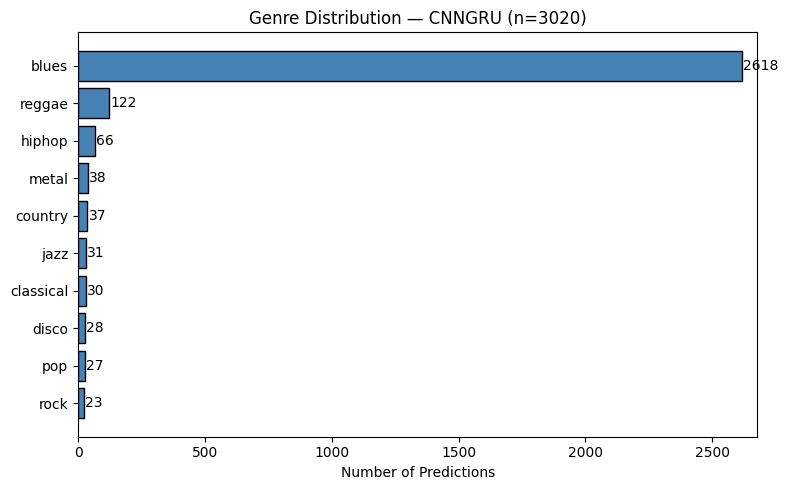

In [68]:
# ── CELL 24: Genre Distribution Plot ──────────────────────────────────────────
import matplotlib.pyplot as plt

genre_counts = submission['genre'].value_counts().sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.barh(genre_counts.index, genre_counts.values, color='steelblue', edgecolor='black')

for bar, val in zip(bars, genre_counts.values):
    ax.text(bar.get_width() + 5, bar.get_y() + bar.get_height() / 2,
            str(val), va='center', fontsize=10)

ax.set_xlabel('Number of Predictions')
ax.set_title(f'Genre Distribution — {MODEL.upper()} (n={len(submission)})')
ax.set_xlim(0, genre_counts.max() + 60)
plt.tight_layout()
plt.savefig('/kaggle/working/genre_distribution.png', dpi=150)
plt.show()
